<a href="https://colab.research.google.com/github/giuliabugatti09/Protecting-the-Future-of-Digital-Work/blob/main/ML_GS2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🤖 AI Impact on Professions: Predictive Analysis**

## **1. Introduction: Navigating the Future of Digital Work**

In a labor market increasingly shaped by Artificial Intelligence, automation, and data-driven decisions, digital platforms are emerging to redefine how we learn, collaborate, and work. These solutions—ranging from continuous learning to corporate well-being and talent management—rely on **secure, ethical, and trustworthy environments**.

In this scenario, cybersecurity and ethical AI become essential pillars. They ensure that technological innovation is used responsibly, protecting both sensitive information and the human beings behind the data in an AI-driven world.

### **The Challenge & Our Mission**

While platform security is vital, a fundamental part of protecting the future of work is understanding the **human impact** of this transformation. How can we ensure professionals are not left behind?

**The objective of this project** is to utilize Machine Learning as a predictive tool to navigate this shift. We developed a robust solution capable of analyzing occupational data and human skills to **forecast the impact of AI across various professions**.

Our analysis seeks to answer critical questions:
* What is the automation risk for a specific occupation?
* What is the urgent need for reskilling in certain sectors?
* Where is the greatest potential for AI to **augment** human productivity rather than replace it?

### **The Solution: An End-to-End ML Pipeline**

To achieve these goals, we built a comprehensive data pipeline that transforms raw data into actionable insights. Our approach is divided into four main stages:

1.  **Exploratory Data Analysis (EDA):** Deep diving into the `AI Impact on Job Market` dataset to extract initial insights, identify influential variables, and understand automation trends by industry.
2.  **Unsupervised Learning (Clustering):** Implementing **K-Means** to group professions with similar characteristics, revealing "occupational archetypes" facing similar risks and opportunities.
3.  **Supervised Learning (Classification):** Training and optimizing a classification model (using **GridSearchCV**) to predict the AI impact level for any profession based on its core features.
4.  **Interactive Inference (Streamlit):** Developing a web application where users can input job characteristics and receive instant, interpretable predictions from the model.

### **Report Structure**

In the following sections, we will detail each step of this pipeline—from initial data exploration to the deployment of the interactive tool—demonstrating how Machine Learning serves as a fundamental ally for a safer and better-prepared future of work.


## 2. Libraries & Dataset Loading


In [1]:
# Standard Data Science stack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Scikit-Learn: Preprocessing & Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Scikit-Learn: Machine Learning Algorithms
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Advanced Modeling
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Plotting configuration
sns.set_theme(style="whitegrid")
%matplotlib inline

# --- DATASET LOADING ---
try:
    # Adjust the filename if yours is different (e.g., 'ai_job_market.csv')
    df = pd.read_csv('/content/ai_job_trends_dataset (1).csv')
    print(f"✅ Success: Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
except FileNotFoundError:
    print("❌ Error: Dataset file not found. Please check the file path.")

✅ Success: Dataset loaded with 30000 rows and 13 columns.


## 3. Initial Inspection


In [2]:
# Displaying the first 5 rows to understand the data structure
print("\n--- First 5 Rows ---")
display(df.head())

# Technical summary of the columns
print("\n--- DataFrame Information ---")
df.info()

# Checking for missing values
print("\n--- Missing Values Check ---")
print(df.isnull().sum())

# Checking for duplicate entries
print(f"\n--- Duplicate Rows: {df.duplicated().sum()} ---")


--- First 5 Rows ---


,Job Title,Industry,Job Status,AI Impact Level,Median Salary (USD),Required Education,Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Location,Gender Diversity (%)
0,Investment analyst,IT,Increasing,Moderate,42109.76,Master’s Degree,5,1515,6342,55.96,28.28,UK,44.63
1,"Journalist, newspaper",Manufacturing,Increasing,Moderate,132298.57,Master’s Degree,15,1243,6205,16.81,89.71,USA,66.39
2,Financial planner,Finance,Increasing,Low,143279.19,Bachelor’s Degree,4,3338,1154,91.82,72.97,Canada,41.13
3,Legal secretary,Healthcare,Increasing,High,97576.13,Associate Degree,15,7173,4060,1.89,99.94,Australia,65.76
4,Aeronautical engineer,IT,Increasing,Low,60956.63,Master’s Degree,13,5944,7396,53.76,37.65,Germany,72.57



--- DataFrame Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job Title                    30000 non-null  object 
 1   Industry                     30000 non-null  object 
 2   Job Status                   30000 non-null  object 
 3   AI Impact Level              30000 non-null  object 
 4   Median Salary (USD)          30000 non-null  float64
 5   Required Education           30000 non-null  object 
 6   Experience Required (Years)  30000 non-null  int64  
 7   Job Openings (2024)          30000 non-null  int64  
 8   Projected Openings (2030)    30000 non-null  int64  
 9   Remote Work Ratio (%)        30000 non-null  float64
 10  Automation Risk (%)          30000 non-null  float64
 11  Location                     30000 non-null  object 
 12  Gender Diversity (%)         30000 non-null

Perfect, Giulia. A professional Data Dictionary is essential for the **"Documentation"** part of your project. It shows that you understand the business context of the data, not just the code.

Here is the translated and polished version for your notebook:

---

## **3. Data Dictionary**

To correctly interpret our analysis, it is crucial to define what each variable represents within the dataset:

* **`Job Title`**:
    * **Description:** The specific name of the job position or professional occupation.
* **`Industry`**:
    * **Description:** The economic sector or industry to which the profession belongs (e.g., IT, Healthcare, Finance).
* **`Median Salary (USD)`**:
    * **Description:** The annual median salary for the occupation, expressed in US Dollars.
* **`Experience Required (Years)`**:
    * **Description:** The median number of years of professional experience required for the qualification.
* **`Required Education`**:
    * **Description:** The level of formal education required for the role (e.g., Bachelor's, Master's, PhD).
* **`Job Openings (2024)`**:
    * **Description:** The number of estimated or available job vacancies for the occupation in the year 2024.
* **`Projected Openings (2030)`**:
    * **Description:** A projection of the estimated number of job vacancies for the occupation by the year 2030.
* **`Remote Work Ratio (%)`**:
    * **Description:** The percentage of professionals in this occupation who work remotely.
* **`Automation Risk (%)`**:
    * **Description:** The estimated probability (percentage) that the core tasks of the occupation will be automated.
* **`AI Impact Level`**:
    * **Description:** A categorical classification of the intensity of AI impact on the profession (e.g., High, Moderate, Low).
* **`Location`**:
    * **Description:** The country or geographical region where the company or job is located.
* **`Gender Diversity (%)`**:
    * **Description:** The percentage of gender representation in the occupation (usually reflecting female representation).

##4. Exploratory Data Analysis (Visual Insights)

###4.1. Which industries face the highest Automation Risk?

This analysis reveals a crucial insight: AI impact is not isolated to purely technical sectors.

/tmp/ipykernel_34246/1998299761.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


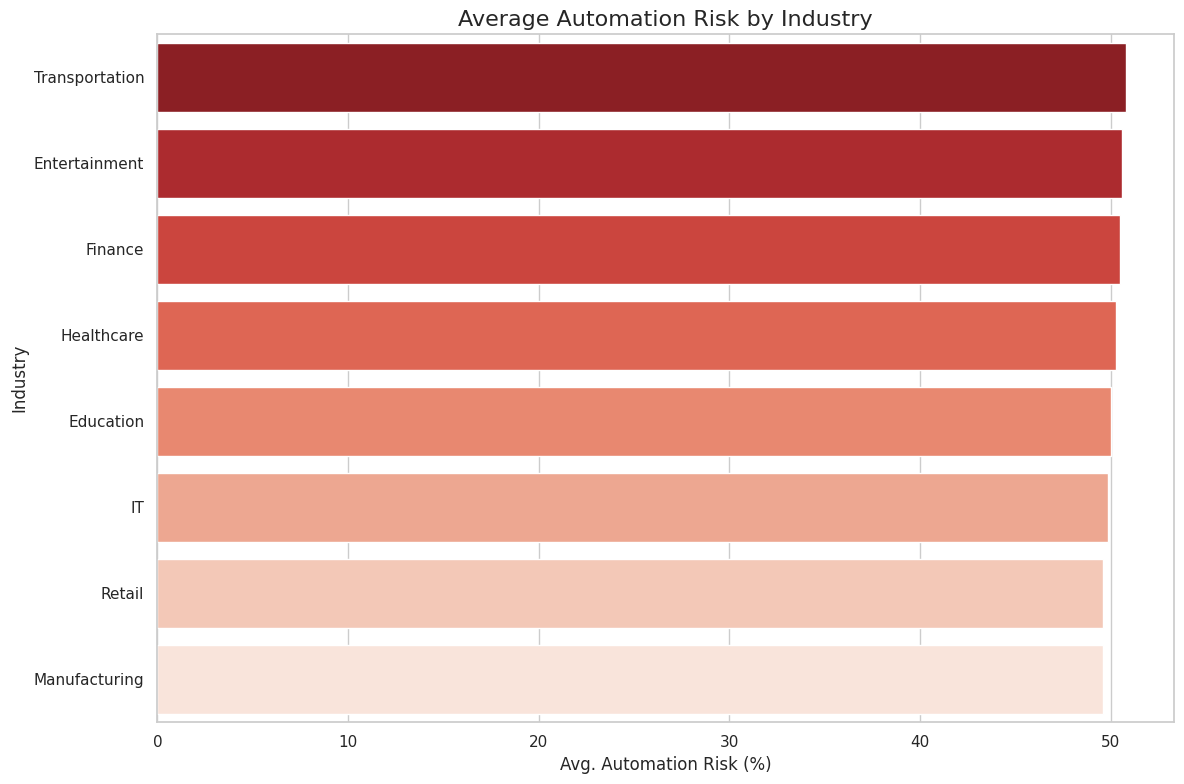


--- Top 5 Industries by Risk ---


,Industry,Automation Risk (%)
0,Transportation,50.79
1,Entertainment,50.59
2,Finance,50.51
3,Healthcare,50.27
4,Education,50.01


In [3]:
# Grouping by Industry and calculating the mean automation risk
industry_col = 'Industry'
risk_col = 'Automation Risk (%)'

if industry_col in df.columns and risk_col in df.columns:
    # Calculate average risk and sort
    risk_by_industry = df.groupby(industry_col)[risk_col].mean().sort_values(ascending=False).reset_index()
    risk_by_industry[risk_col] = risk_by_industry[risk_col].round(2)

    # Visualization
    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=risk_by_industry,
        x=risk_col,
        y=industry_col,
        palette="Reds_r" # High risk = Darker red
    )

    plt.title('Average Automation Risk by Industry', fontsize=16)
    plt.xlabel('Avg. Automation Risk (%)', fontsize=12)
    plt.ylabel('Industry', fontsize=12)
    plt.tight_layout()
    plt.show()

    print("\n--- Top 5 Industries by Risk ---")
    display(risk_by_industry.head())

Interpretation: While Transportation often leads due to autonomous vehicles, industries like Healthcare and Education also show risks above 50%. This suggests that automation is becoming generalized, moving from routine physical tasks to complex administrative and diagnostic functions.

###4.2. Correlation Matrix: Which variables drive AI Impact?

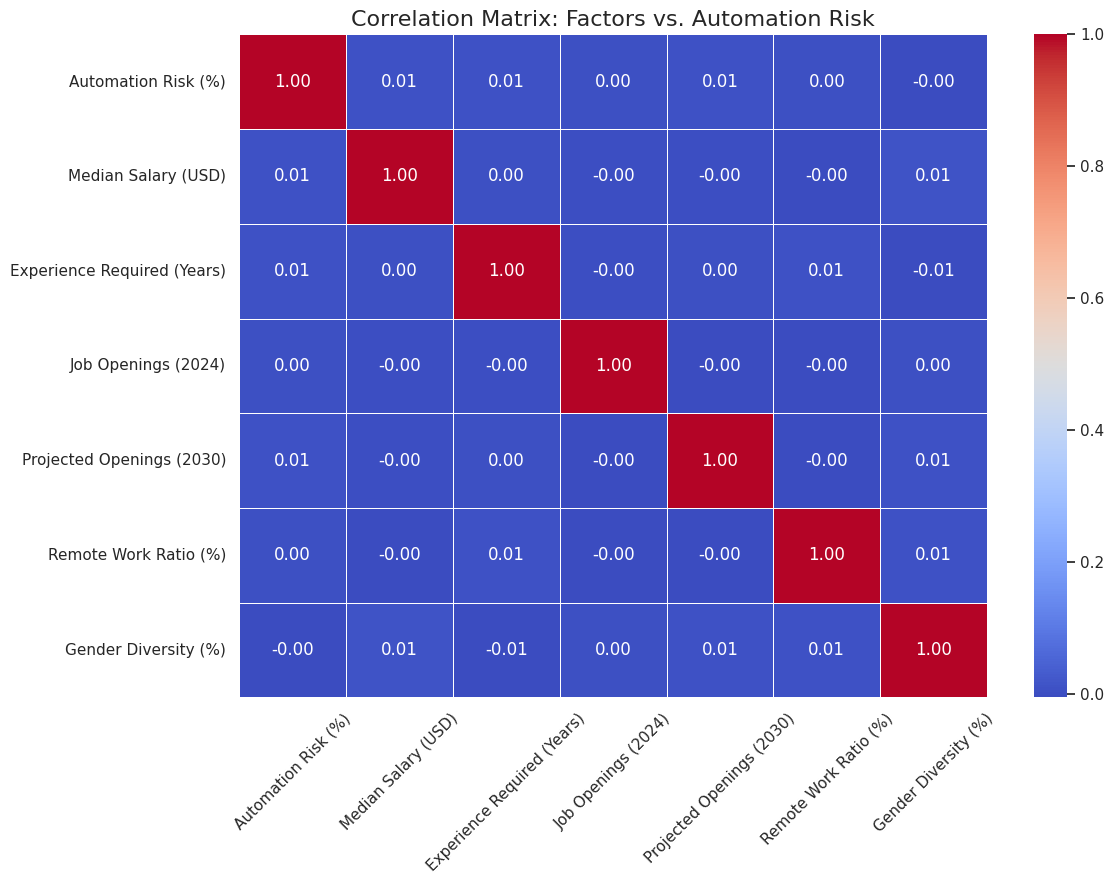


--- Correlation with Automation Risk ---
Automation Risk (%)            1.000000
Median Salary (USD)            0.007980
Projected Openings (2030)      0.007434
Experience Required (Years)    0.006541
Remote Work Ratio (%)          0.004851
Job Openings (2024)            0.003284
Gender Diversity (%)          -0.003737
Name: Automation Risk (%), dtype: float64


In [4]:
# Selecting relevant numerical variables
relevant_vars = [
    'Automation Risk (%)',
    'Median Salary (USD)',
    'Experience Required (Years)',
    'Job Openings (2024)',
    'Projected Openings (2030)',
    'Remote Work Ratio (%)',
    'Gender Diversity (%)'
]

# Filter existing columns
existing_vars = [col for col in relevant_vars if col in df.columns]

if len(existing_vars) > 1:
    # Calculating the correlation matrix
    corr_matrix = df[existing_vars].corr()

    # Heatmap Visualization
    plt.figure(figsize=(12, 9))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='coolwarm', # Red = Positive, Blue = Negative
        fmt='.2f',
        linewidths=0.5
    )
    plt.title('Correlation Matrix: Factors vs. Automation Risk', fontsize=16)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Highest correlations with target
    if 'Automation Risk (%)' in corr_matrix:
        target_corr = corr_matrix['Automation Risk (%)'].sort_values(ascending=False)
        print("\n--- Correlation with Automation Risk ---")
        print(target_corr)

Analysis: The heatmap reveals a surprising result: there is almost zero linear correlation between Automation Risk (%) and other numerical variables like Median Salary (0.01) or Experience (0.01).

Conclusion: Factors like salary or seniority are not good individual predictors for automation. This proves that the nature of the work (encoded in categorical variables like Industry or Job Title) is what truly defines the risk.

### 4.3. AI Augmentation vs. Automation Risk

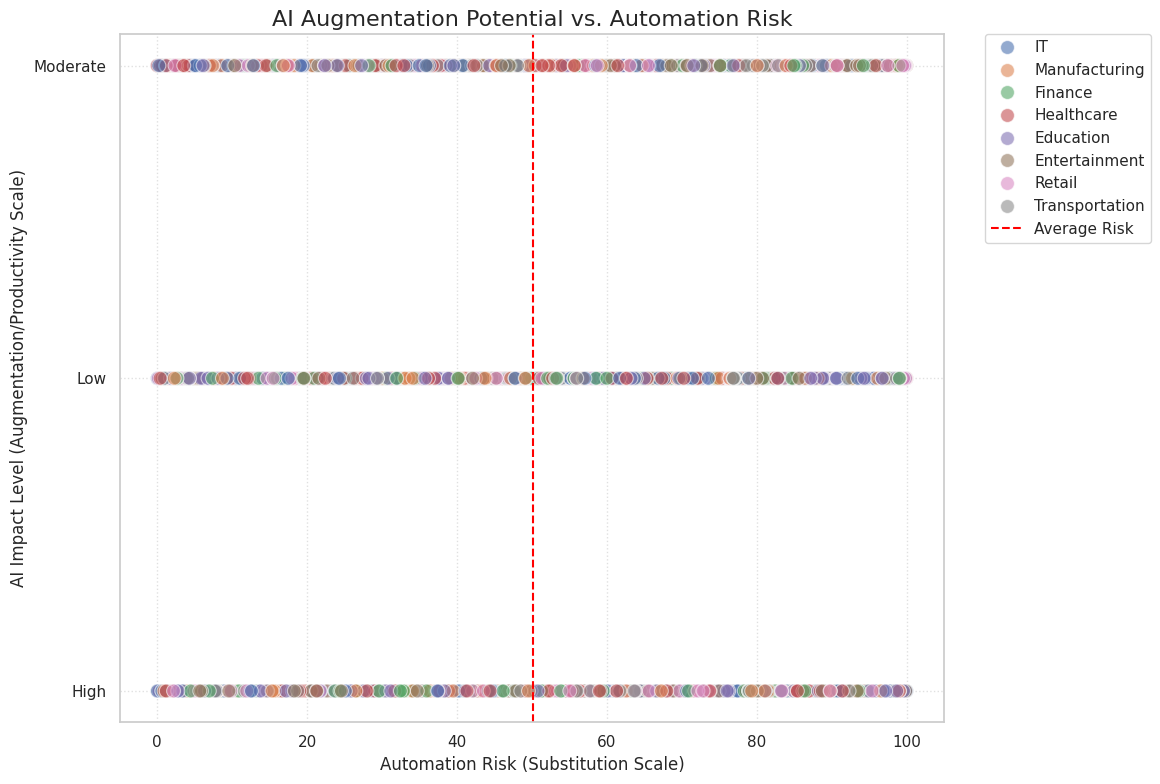

In [5]:
# Variables for analysis
risk_col = 'Automation Risk (%)'
impact_col = 'AI Impact Level'
industry_col = 'Industry'

if risk_col in df.columns and impact_col in df.columns:
    plt.figure(figsize=(14, 8))

    # Scatterplot to show individual occupations
    sns.scatterplot(
        data=df,
        x=risk_col,
        y=impact_col,
        hue=industry_col if industry_col in df.columns else None,
        alpha=0.6,
        s=100
    )

    plt.title('AI Augmentation Potential vs. Automation Risk', fontsize=16)
    plt.xlabel('Automation Risk (Substitution Scale)', fontsize=12)
    plt.ylabel('AI Impact Level (Augmentation/Productivity Scale)', fontsize=12)

    # Average risk reference line
    if pd.api.types.is_numeric_dtype(df[risk_col]):
        plt.axvline(df[risk_col].mean(), color='red', linestyle='--', label='Average Risk')

    # Legend outside the plot
    if industry_col in df.columns:
        plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

else:
    print(f"❌ Error: Check column names '{risk_col}' or '{impact_col}'.")

Interpretation: The scatterplot provides a clear answer: Augmentation and Substitution are independent variables.

We see clear horizontal bands (High, Moderate, Low impact). Even in the "High Risk" zone (>80% automation), there are many professions in the "High" impact category.

Conclusion: Even if AI automates 80% of a job's tasks, the remaining 20%—which require human strategy, empathy, or creativity—become exponentially more valuable. AI acts as a productivity amplifier, freeing humans from routine work to focus on high-value activities.

## 5. Data Preprocessing & Feature Engineering

In [6]:
# 5.1. Defining Features (X) and Target (y)
target_col = 'AI Impact Level'
drop_cols = [target_col, 'Job Title'] # Job Title is too specific for training

if target_col in df.columns:
    # Dropping missing targets if any
    clean_df = df.dropna(subset=[target_col])

    X = clean_df.drop(drop_cols, axis=1)
    y_raw = clean_df[target_col]

    # 5.2. Target Encoding (High, Low, Moderate -> 0, 1, 2)
    le = LabelEncoder()
    y = le.fit_transform(y_raw)

    print(f"✅ Target processed. Classes detected: {list(le.classes_)}")
    print(f"Features (X) shape: {X.shape}")
else:
    print("❌ Error: Target column not found.")

# 5.3. Identifying Feature Types for the Pipeline
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numerical features ({len(num_features)}): {num_features}")
print(f"Categorical features ({len(cat_features)}): {cat_features}")

✅ Target processed. Classes detected: ['High', 'Low', 'Moderate']
Features (X) shape: (30000, 11)
Numerical features (7): ['Median Salary (USD)', 'Experience Required (Years)', 'Job Openings (2024)', 'Projected Openings (2030)', 'Remote Work Ratio (%)', 'Automation Risk (%)', 'Gender Diversity (%)']
Categorical features (4): ['Industry', 'Job Status', 'Required Education', 'Location']


In [7]:
# Numerical Transformer: Standardizes features (mean=0, std=1)
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical Transformer: Converts text labels into Binary Vectors (One-Hot Encoding)
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combining both into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ],
    remainder='passthrough' # Keeps any other columns that don't need transform
)

# 5.2. Train-Test Split
# We use 20% for testing and 80% for training.
# Stratify=y ensures the same proportion of High/Low/Moderate in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"✅ Data successfully split and preprocessed.")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# 5.3. Applying the fit_transform (Visual Diagnostic)
# We fit only on training data to avoid leaking test info into the training phase
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Final processed feature count: {X_train_processed.shape[1]}")

✅ Data successfully split and preprocessed.
Training set: 24000 samples
Testing set: 6000 samples
Final processed feature count: 30



- `High'` = 0
- `'Low'` = 1
- `'Moderate'` = 2

## 6. Supervised learning

In [8]:
# 6.1. Defining Model Grids
# We store the pipelines and parameters in a dictionary for easy iteration
models_to_test = {
    'LogisticRegression': (
        Pipeline(steps=[('pre', preprocessor), ('model', LogisticRegression(max_iter=1000, random_state=42))]),
        {'model__C': [0.1, 1.0, 10]}
    ),
    'RandomForest': (
        Pipeline(steps=[('pre', preprocessor), ('model', RandomForestClassifier(random_state=42))]),
        {'model__n_estimators': [100, 200], 'model__max_depth': [None, 10, 20]}
    ),
    'XGBoost': (
        Pipeline(steps=[('pre', preprocessor), ('model', XGBClassifier(random_state=42, eval_metric='mlogloss'))]),
        {'model__learning_rate': [0.01, 0.1], 'model__n_estimators': [100, 150]}
    )
}

best_estimators = {}

print("--- Starting GridSearchCV Optimization ---")
for name, (pipeline, params) in models_to_test.items():
    print(f"Training {name}...")
    grid = GridSearchCV(pipeline, params, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train) # Here we pass the raw X_train because the pipeline handles the preprocessor

    print(f"Best CV Accuracy: {grid.best_score_:.4f}")
    best_estimators[name] = grid.best_estimator_

print("\n--- Final Evaluation on Test Set ---")
for name, model in best_estimators.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Final {name} Test Accuracy: {acc:.4f}")

--- Starting GridSearchCV Optimization ---
Training LogisticRegression...
Best CV Accuracy: 0.3369
Training RandomForest...
Best CV Accuracy: 0.3378
Training XGBoost...
Best CV Accuracy: 0.3372

--- Final Evaluation on Test Set ---
Final LogisticRegression Test Accuracy: 0.3312
Final RandomForest Test Accuracy: 0.3318
Final XGBoost Test Accuracy: 0.3298


##7. Unsupervised Learning: K-Means Clustering


### 7.1. Finding the Optimal Number of Clusters (Elbow Method)

We use the WCSS (Within-Cluster Sum of Squares) to identify the "elbow" point where adding more clusters no longer significantly improves the model.

Calculating WCSS for the Elbow Method...


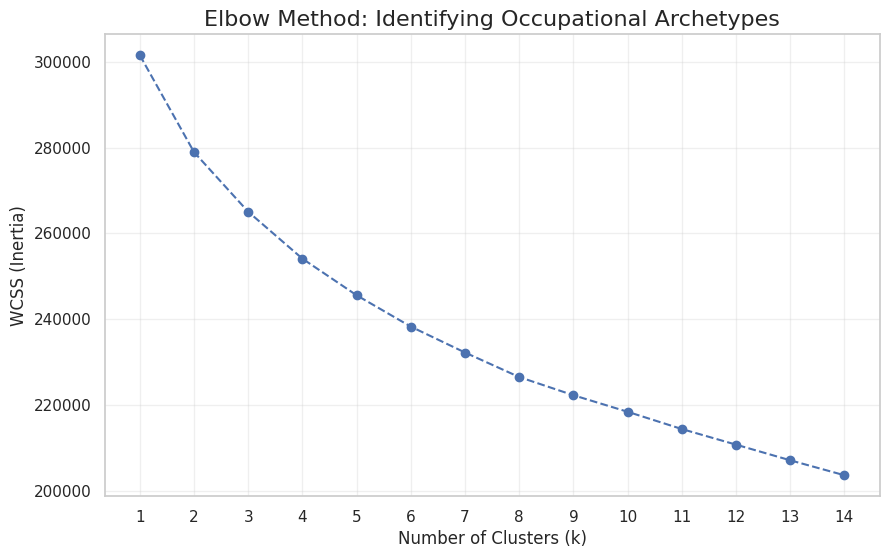

In [9]:
# We use the processed features (all numerical and encoded categorical)
# to feed the K-Means algorithm.
X_processed_all = preprocessor.fit_transform(X)

wcss = []
k_range = range(1, 15)

print("Calculating WCSS for the Elbow Method...")
for k in k_range:
    kmeans_elbow = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans_elbow.fit(X_processed_all)
    wcss.append(kmeans_elbow.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method: Identifying Occupational Archetypes', fontsize=16)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

### 7.2. Applying K-Means & PCA Visualization

Based on your previous analysis, we chose k=10 to capture the granular differences between "Resilient", "Vulnerable", and "In Transition" roles. We use PCA (Principal Component Analysis) to flatten the high-dimensional data into 2D so we can visualize the clusters.

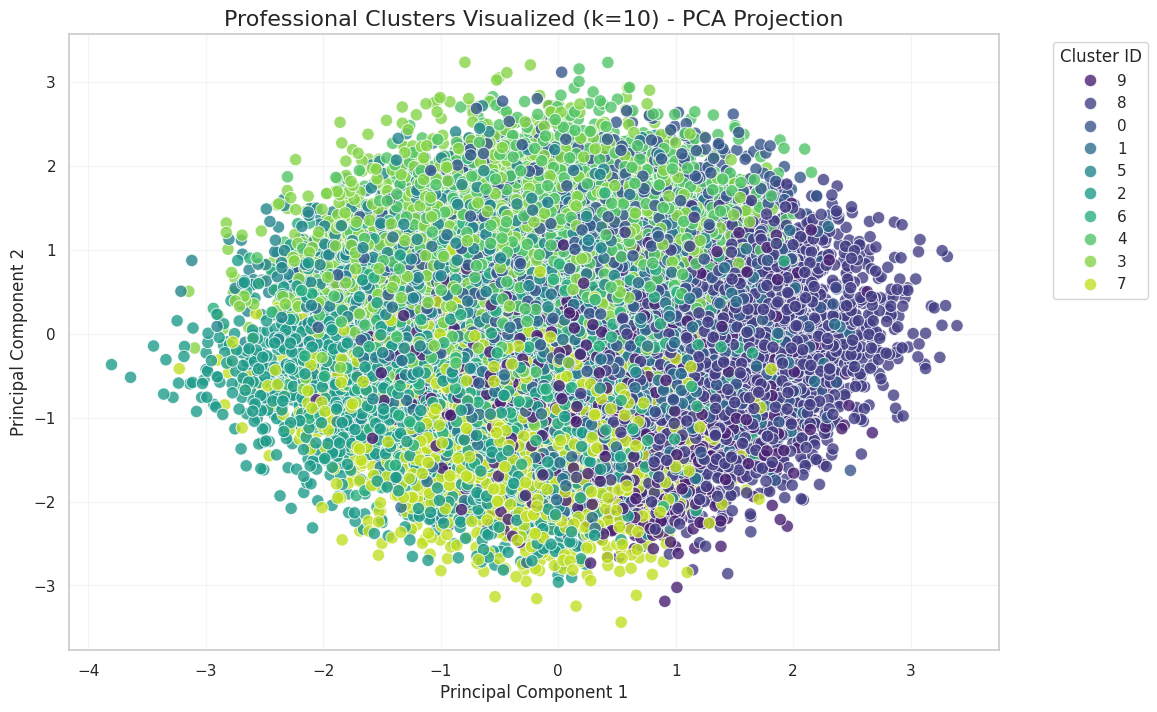

In [10]:
# 1. Applying the Final K-Means
optimal_k = 10
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_processed_all)

# 2. Dimensionality Reduction with PCA (For Visualization Only)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed_all)

# 3. Creating a Visualization DataFrame
df_clusters = df.copy()
df_clusters['Cluster'] = cluster_labels

df_viz = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_viz['Cluster'] = cluster_labels.astype(str)

# 4. Plotting the Clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_viz,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='viridis',
    s=80,
    alpha=0.8
)
plt.title(f'Professional Clusters Visualized (k={optimal_k}) - PCA Projection', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc=2)
plt.grid(True, alpha=0.2)
plt.show()

## 8. Saving Model Artifacts for Deployment

In [11]:
# Create the models directory if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

# Select the best model from our benchmark (e.g., XGBoost)
final_model = best_estimators['XGBoost']

# Save the Pipeline (this includes the preprocessor + the classifier)
joblib.dump(final_model, 'models/ai_impact_model.pkl')

# Save the Label Encoder to decode 'High/Low/Moderate'
joblib.dump(le, 'models/label_encoder.pkl')

print("✅ Success! All models and pipelines saved in 'models/' folder.")

✅ Success! All models and pipelines saved in 'models/' folder.
